In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
print("Читаем локальный файл mnist_train.csv...")

df = pd.read_csv('mnist_train.csv')

Читаем локальный файл mnist_train.csv...


In [3]:
if 'label' in df.columns:
    y = df['label'].values
    X = df.drop(columns=['label']).values
else:
    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values
    
print(f"Полный датасет загружен. Формат: {X.shape}")

Полный датасет загружен. Формат: (60000, 784)


In [4]:
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=5000, stratify=y, random_state=42)

X_sample = X_sample / 255.0

print(f"Данные готовы! Формат выборки: {X_sample.shape}")

Данные готовы! Формат выборки: (5000, 784)


In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

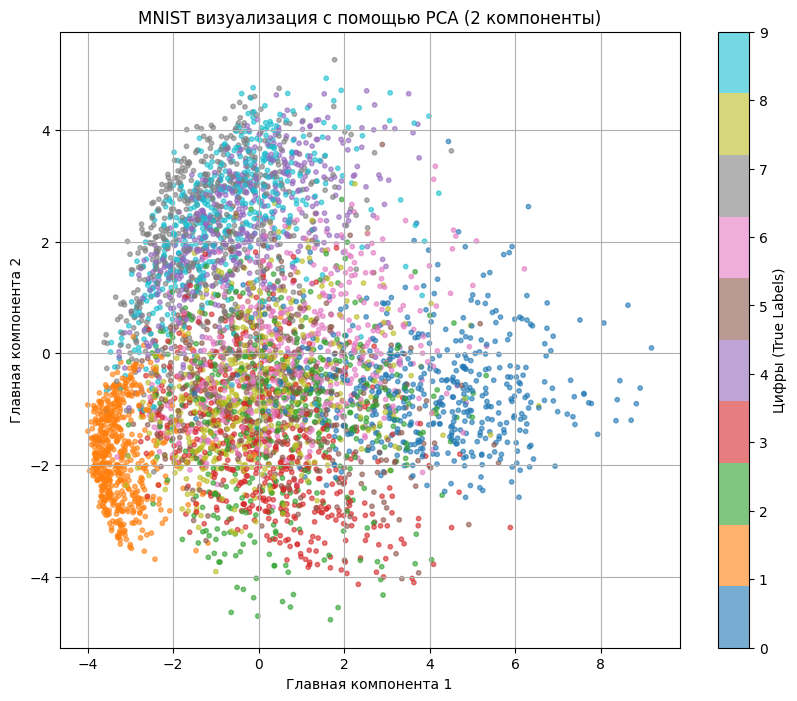

In [6]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, label='Цифры (True Labels)')
plt.title('MNIST визуализация с помощью PCA (2 компоненты)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.grid(True)
plt.show()

In [7]:
print("Запуск t-SNE... Это может занять около 20-30 секунд.")

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)

Запуск t-SNE... Это может занять около 20-30 секунд.


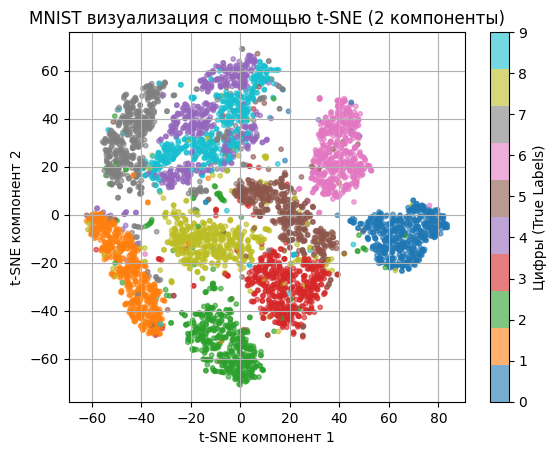

In [8]:
plt.Figure(figsize=(10, 8))
scatter_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter_tsne, label='Цифры (True Labels)')
plt.title('MNIST визуализация с помощью t-SNE (2 компоненты)')
plt.xlabel('t-SNE компонент 1')
plt.ylabel('t-SNE компонент 2')
plt.grid(True)
plt.show()

In [9]:
inertia_values = []
silhouette_values = []

k_range = range(2, 16)

In [10]:
print("Запуск K-Means для k от 2 до 15...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_sample)
    
    inertia_values.append(kmeans.inertia_)
    
    sil_score = silhouette_score(X_sample, kmeans.labels_)
    silhouette_values.append(sil_score)
    print(f"При k={k}: Инерция = {kmeans.inertia_:.2f}, Силуэт = {sil_score:.4f}")

Запуск K-Means для k от 2 до 15...
При k=2: Инерция = 247009.95, Силуэт = 0.0937
При k=3: Инерция = 235077.59, Силуэт = 0.0541
При k=4: Инерция = 226235.66, Силуэт = 0.0570
При k=5: Инерция = 217731.37, Силуэт = 0.0647
При k=6: Инерция = 211646.63, Силуэт = 0.0639
При k=7: Инерция = 207469.38, Силуэт = 0.0510
При k=8: Инерция = 203138.93, Силуэт = 0.0715
При k=9: Инерция = 199351.64, Силуэт = 0.0563
При k=10: Инерция = 196688.29, Силуэт = 0.0585
При k=11: Инерция = 194251.30, Силуэт = 0.0586
При k=12: Инерция = 191575.26, Силуэт = 0.0578
При k=13: Инерция = 189144.09, Силуэт = 0.0589
При k=14: Инерция = 187182.28, Силуэт = 0.0584
При k=15: Инерция = 185664.40, Силуэт = 0.0475


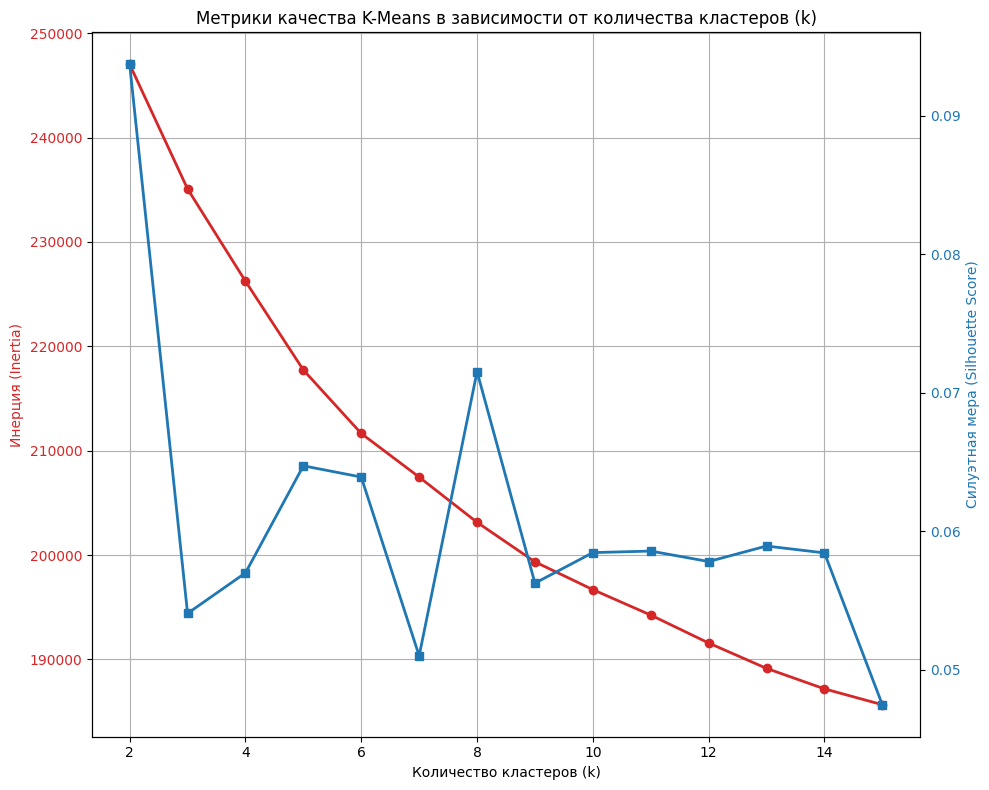

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 8))

color = 'tab:red'
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('Инерция (Inertia)', color=color)
ax1.plot(k_range, inertia_values, marker='o', color=color, linewidth=2, label='Инерция')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Силуэтная мера (Silhouette Score)', color=color)
ax2.plot(k_range, silhouette_values, marker='s', color=color, linewidth=2, label='Инерция')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Метрики качества K-Means в зависимости от количества кластеров (k)')
fig.tight_layout()
plt.show()

In [12]:
optimal_k = 10
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters_labels = kmeans_final.fit_predict(X)

In [13]:
centroids = kmeans_final.cluster_centers_

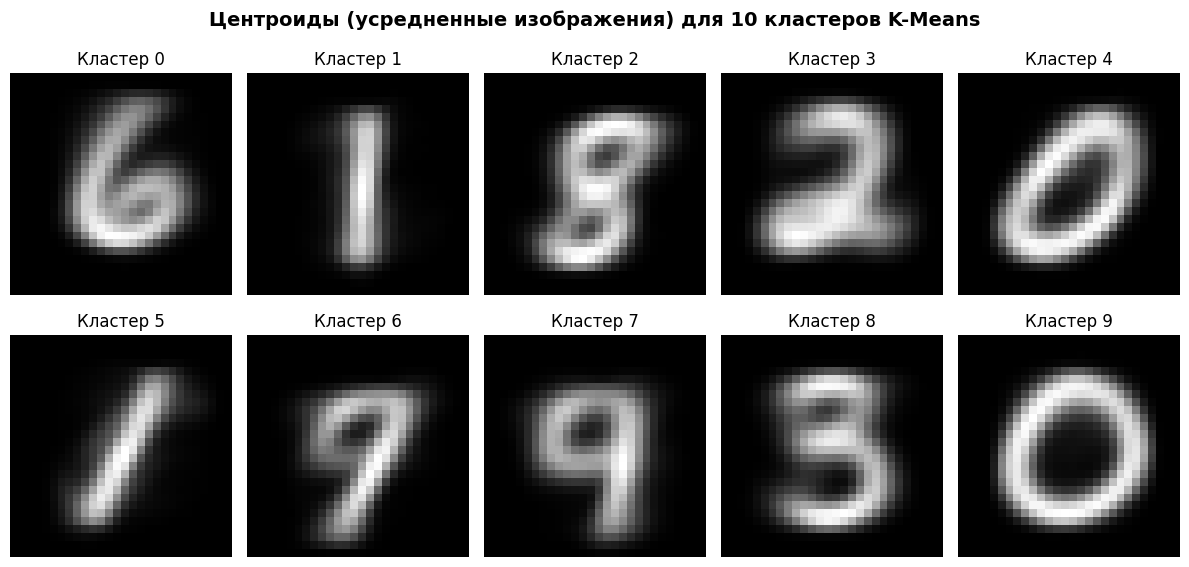

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.ravel()):
    centroid_image = centroids[i].reshape(28, 28)
    
    ax.imshow(centroid_image, cmap='gray')
    ax.set_title(f'Кластер {i}')
    ax.axis('off')

plt.suptitle('Центроиды (усредненные изображения) для 10 кластеров K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()